In [1]:
import mysql.connector 
import pandas as pd 
import numpy as np

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="********",
    database ="financial_risk_system"
)

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
query = "Select * from customer_features"
df = pd.read_sql(query,conn)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17440\219173841.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [26]:
df.head()

,Customer_id,Age,Income,Credit_score,transaction_count,total_spending,avg_transaction_value,total_loans,total_defaults,total_loan_amount,default_rate,default_flag,spending_income_ratio,loan_income_ratio,transaction_income_ratio
0,1,55,97575.0,512,3,3378.060059,1126.020020,0,0.0,0.0,0.0,0,0.034620,0.000000,0.000031
1,2,45,105335.0,709,2,1896.730049,948.365025,1,0.0,98352.0,0.0,0,0.018007,0.933707,0.000019
2,3,45,79421.0,418,7,8530.969925,1218.709989,0,0.0,0.0,0.0,0,0.107415,0.000000,0.000088
3,4,51,35188.0,790,6,4561.029892,760.171649,1,0.0,200784.0,0.0,0,0.129619,5.706036,0.000171
4,5,47,101101.0,434,6,5428.189896,904.698316,1,0.0,174948.0,0.0,0,0.053691,1.730428,0.000059


In [4]:
df["spending_income_ratio"] = df["total_spending"] / df["Income"]
df["loan_income_ratio"] = df["total_loan_amount"] / df["Income"]
df["transaction_income_ratio"] = df["transaction_count"] / df["Income"]

In [5]:
X = df.drop(columns=["default_flag"])
y = df["default_flag"]

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Now we start with baseline model - Logistic regression

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(confusion_matrix(y_test,y_pred))

[[1808    0]
 [   0  192]]


In [9]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1808
           1       1.00      1.00      1.00       192

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### From confusion metric -> we can see model predicted every single case correctly , In a real credit dataset this would be extraordinarily unlikely

In [10]:
X = df.drop(columns=[
    'Customer_id',
    'default_flag',
    'total_defaults',
    'default_rate'
])
y=df['default_flag']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test,y_pred))

[[1774   34]
 [ 166   26]]


In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      1808
           1       0.43      0.14      0.21       192

    accuracy                           0.90      2000
   macro avg       0.67      0.56      0.58      2000
weighted avg       0.87      0.90      0.88      2000



#### Still , Accuracy is 90% but still misleading , as we see accuracy is good but model is still fails to detect defaults ( Aim of project )                                                                                                               

#### From Recall we can see , model correctly detects only 11% of defaulters ( Out of 193 defaulters , it correctly finds only about 21)

## Q). Why Logistic regression struggles here

## Handle Class Imbalance (LR)

In [14]:
# Instead of normal logistic regression, we give higher importance to default cases.
model = LogisticRegression(
    max_iter=4000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [15]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test,y_pred))

[[1286  522]
 [  13  179]]


In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.71      0.83      1808
           1       0.26      0.93      0.40       192

    accuracy                           0.73      2000
   macro avg       0.62      0.82      0.61      2000
weighted avg       0.92      0.73      0.79      2000



## Now we try this data on Random forest as Tree models work very well on non-linear(financial behaviour pattern)

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [18]:
print(confusion_matrix(y_test, y_pred_rf))

[[1793   15]
 [ 184    8]]


In [19]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1808
           1       0.35      0.04      0.07       192

    accuracy                           0.90      2000
   macro avg       0.63      0.52      0.51      2000
weighted avg       0.85      0.90      0.86      2000



## Handle Class Imbalance (RF)

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=9,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [36]:
print(confusion_matrix(y_test, y_pred_rf))

[[1238  570]
 [   3  189]]


Nothing happens , same result as for LR only it is something good in case of non-defaulters 

In [22]:
y_prob = rf.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.35).astype(int)

In [23]:
print(confusion_matrix(y_test, y_pred_custom))

[[1238  570]
 [   3  189]]


### Both balanced logistic regression and random forest produced similar risk-detection performance after threshold tuning. This suggests that the engineered financial features capture most of the predictive signal in a nearly linear manner. Therefore, logistic regression may be preferred for deployment due to its simplicity and interpretability

## so using GridSearchCv look for the best parameters we can use for Random Forest

# Not run this Again (time taking)

In [34]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators":[100,200,300,400,500],
    "max_depth":[8,10,12,14,16],
    "min_samples_split":[2,5,8,11,14],
    "min_samples_leaf":[1,3,5,7,9]
}
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 2, 'n_estimators': 300}


## Now we try to understand which features contribute how much in model using SHAP

In [24]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [28]:
shap_values.shape

(2000, 11, 2)

In [29]:
X_test.shape

(2000, 11)

In [30]:
shap_values

array([[[ 2.45020381e-04, -2.45020381e-04],
        [ 5.21058016e-03, -5.21058016e-03],
        [ 1.87828938e-03, -1.87828938e-03],
        ...,
        [ 1.02657665e-02, -1.02657665e-02],
        [ 2.00419179e-01, -2.00419179e-01],
        [ 3.67184218e-03, -3.67184218e-03]],

       [[ 6.03014209e-04, -6.03014209e-04],
        [ 9.34402502e-03, -9.34402502e-03],
        [ 4.08393580e-03, -4.08393580e-03],
        ...,
        [ 5.72675602e-03, -5.72675602e-03],
        [ 1.91349460e-01, -1.91349460e-01],
        [ 1.09383500e-02, -1.09383500e-02]],

       [[ 3.62853934e-02, -3.62853934e-02],
        [ 9.01642722e-03, -9.01642722e-03],
        [ 3.86675082e-03, -3.86675082e-03],
        ...,
        [ 1.05862865e-02, -1.05862865e-02],
        [ 1.46447226e-01, -1.46447226e-01],
        [ 4.44107822e-02, -4.44107822e-02]],

       ...,

       [[ 6.15398217e-04, -6.15398217e-04],
        [ 8.75515962e-04, -8.75515962e-04],
        [ 4.72568704e-03, -4.72568704e-03],
        ...,
     

In [31]:
shap_values_class1 = shap_values[:,:,1]

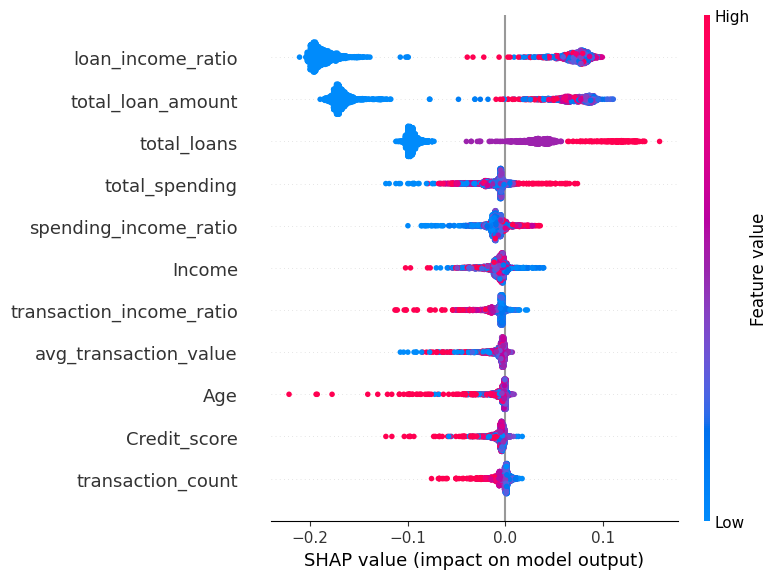

In [32]:
shap.summary_plot(shap_values_class1,X_test)

from 0.0 :
Right side → pushes prediction toward default , 
Left side → pushes prediction toward non-default

### So as expected high ( loan_amount_ratio , total_loan_amount , total_loans , total_spending , spending income ratio ) and Low ( income , transaction_income_ratio ) tend to be predicted as higher risk (defaulter)

### Whereas on the protective side Income itsels tends to psuh prediction toward non-defaulter side when it is high , similarly for Age , Credit_score and transaction_count                             and also they are placed at bottom so signifies less importance for defaulters 

# Model identifies debt burden and spending pressure as the strongest drivers of default risk